# GoalLab Stage 08: Compare controllers on one workspace

Created by Shivam Bharadwaj · [Course home](../../../README.md) · [Stage map](../STAGES.md)

[Stage 07](07_preference_and_grpo.ipynb) · [Stage 09](09_small_model_sft_dpo.ipynb)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/apply-theory/08_one_problem_many_algorithms.ipynb)

**Build:** a common evaluation harness comparing seven controllers on the exact same GoalLab task.

**Run:** use the full repository, install `requirements.txt` (Stage 09 also uses `requirements-modern.txt`), then restart the kernel and run all cells. Every stage reconstructs its inputs from shared GoalLab modules; earlier notebook execution is not required. The project progression is cumulative in capabilities, without hidden notebook state.

Code: MIT. Text and plots: CC BY 4.0. Results below are reproduced from the supplied GoalLab cases; the evaluation section explains their scope and failure cases.

**Learn the algorithm first:** [Course Notebook 08](../../../notebooks/08_one_problem_many_algorithms.ipynb). Then use this GoalLab stage to apply it to evidence gathering and briefing verification.


In [1]:
import sys, subprocess, platform, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'rl_course').is_dir()), Path.cwd())
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course' / 'goallab.py').exists():
    raise FileNotFoundError('Use the complete repository revision containing the GoalLab stages.')
sys.path.insert(0, str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course import goallab as goal
from rl_course import goallab_learning as learning
torch.set_num_threads(2)
%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#af824a', '#768165', '#87708c', '#f5f1e8'
plt.rcParams.update({'figure.figsize': (9, 4), 'figure.dpi': 110, 'figure.facecolor': PAPER,
    'axes.facecolor': PAPER, 'text.color': INK, 'axes.labelcolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(str(x).replace('|', '&#124;').replace('\n', '<br>') for x in row) + ' |' for row in rows)))
def learning_plot(runs):
    for label, run in runs.items():
        h = run['history']
        plt.plot(h[:, 0], h[:, 1], label=label)
    plt.xlabel('Training environment actions'); plt.ylabel('Exact policy return')
    plt.legend(); plt.tight_layout(); plt.show()
def report_policies(runs):
    table(['Controller', 'Exact return', 'Held-out briefing success', 'Calls/case'],
          [[label, round(run['env'].values(run['policy'])[0][run['env'].start_index], 3),
            f"{learning.heldout(run['policy'])['success']:.1%}", learning.heldout(run['policy'])['calls']]
           for label, run in runs.items()])
workspace = goal.make_workspace(7, 'test')
print(f'{goal.VERSION} | Python {platform.python_version()} | NumPy {np.__version__} | Torch {torch.__version__} | CPU')

GoalLab-v1 | Python 3.12.4 | NumPy 1.26.4 | Torch 2.11.0+cu130 | CPU


## Shared contract

One source is an approved measurement for the requested period. Other sources are drafts or forecasts, deliberately newer and numerically different. Training rows use 0..3; held-out rows use 4..7 and a different period. Authority rules stay the same. `search` reveals IDs and timestamps; `read` reveals content. A valid briefing needs the correct value, period, and citation.

The simulator and models are readable teaching code, not a security boundary. Final `verify()` is outside the policy interface. The first eight stages use a finite two-source abstraction: read twice, choose a citation, then submit or claim completion. Claiming completion produces no briefing. This fixed horizon makes exact comparisons possible; later stages vary investigation budgets.

## Learning objectives and the stage contract

Control interaction budgets; separate exact and sampled evaluation; interpret seed variation and simple baselines.

**Input:** the shared evidence workspace or the preceding component reconstructed below. **Output:** the capability named in this stage, evaluated against the common briefing contract. Read the worked calculation before running the full experiment; then inspect the implementation and predict the constraint exercise.

## Work it out: specify the denominator before comparing methods

All sampled controllers receive the same environment interactions. A DQN update samples many replay transitions; PPO reuses a rollout; MC computes one return per visit. Equal interactions therefore do not equal equal gradient work.

The exact DP baseline has model access. The deterministic evidence rule has the authority rule built in. Label those information advantages. A production comparison should retain simple baselines even when they outperform the learned methods.

In [2]:
episodes,horizon,seeds=600,4,3
print('Interactions per method/seed:',episodes*horizon)
print('Total training interactions over three seeds:',episodes*horizon*seeds)
print('PPO rollout batches:',episodes//24,'; optimizer epochs per batch: 4')
assert episodes%24==0

Interactions per method/seed: 2400
Total training interactions over three seeds: 7200
PPO rollout batches: 25 ; optimizer epochs per batch: 4


## Build the component

The central implementation is included here so you can step through and edit the update or tool logic. The shared modules retain the same reference implementation for the integrated project. Inspect shapes, terminal handling, frozen quantities, and the evaluator boundary before training.

In [3]:
from collections import deque
from copy import deepcopy
from torch import nn
from torch.distributions import Categorical
EvidenceMDP = goal.EvidenceMDP
greedy = learning.greedy
network = learning.network
train_tabular=learning.train_tabular
train_dqn=learning.train_dqn
train_policy=learning.train_policy
def run_control(seeds=(7, 19, 31), episodes=600):
    results = {}
    for method in ['MC control', 'SARSA', 'Q-learning', 'DQN', 'REINFORCE', 'Actor-Critic', 'PPO']:
        print('GoalLab:', method, flush=True)
        if method in {'MC control', 'SARSA', 'Q-learning'}:
            results[method] = [train_tabular(method, s, episodes) for s in seeds]
        elif method == 'DQN':
            results[method] = [train_dqn(s, episodes) for s in seeds]
        else:
            results[method] = [train_policy(method, s, episodes) for s in seeds]
    return results

## 1. Equal interaction budgets

Every sampled method receives 600 episodes of four actions, per seed. MC and TD prediction from stage 02 are not ranked as controllers. Dynamic programming supplies an exact optimal reference with model access, so it is not charged the same sampled training budget.

Methods receive equal environment actions, not equal optimizer FLOPs. Report this distinction when discussing efficiency.

In [4]:
SEEDS = (7,19,31)
runs = run_control(SEEDS,600)
table(['Method','Mean verified success','Seed SD','Mean exact return'], [[m,
    f"{np.mean([learning.heldout(r['policy'])['success'] for r in rs]):.1%}",
    round(np.std([learning.heldout(r['policy'])['success'] for r in rs],ddof=1),3),
    round(np.mean([r['env'].values(r['policy'])[0][r['env'].start_index] for r in rs]),3)] for m,rs in runs.items()])

GoalLab: MC control


GoalLab: SARSA


GoalLab: Q-learning


GoalLab: DQN


GoalLab: REINFORCE


GoalLab: Actor-Critic


GoalLab: PPO


| Method | Mean verified success | Seed SD | Mean exact return |
|---|---|---|---|
| MC control | 100.0% | 0.0 | 0.92 |
| SARSA | 100.0% | 0.0 | 0.92 |
| Q-learning | 100.0% | 0.0 | 0.92 |
| DQN | 100.0% | 0.0 | 0.92 |
| REINFORCE | 62.7% | 0.137 | 0.558 |
| Actor-Critic | 43.3% | 0.006 | 0.404 |
| PPO | 93.0% | 0.01 | 0.861 |

## 2. Compare learning curves and actual artifacts

Exact return averages over both authority placements and the deployed action distribution. The held-out task score samples concrete workspace records. Keep both and investigate disagreement rather than selecting the more flattering metric.

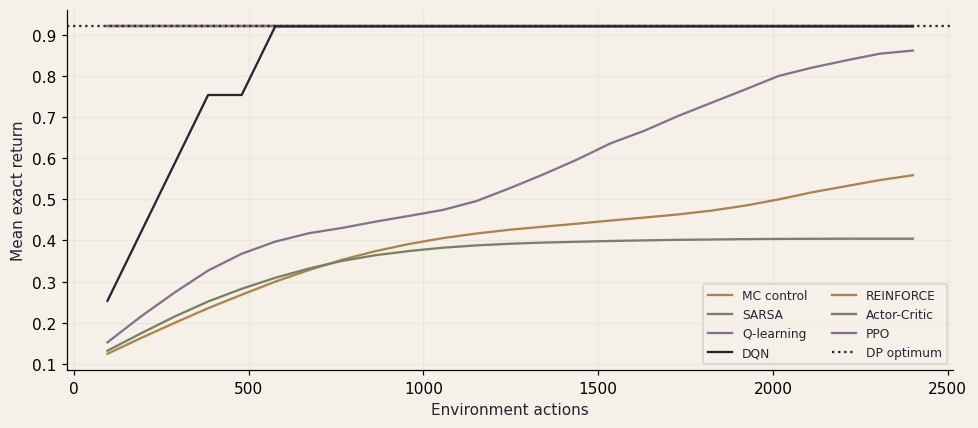

In [5]:
for method,rs in runs.items():
    histories=np.array([r['history'] for r in rs]); plt.plot(histories[0,:,0],histories[:,:,1].mean(0),label=method)
plt.axhline(.92,color=INK,linestyle=':',label='DP optimum'); plt.xlabel('Environment actions'); plt.ylabel('Mean exact return')
plt.legend(ncol=2,fontsize=8); plt.tight_layout(); plt.show()

## Interpret the evidence

The evidence rule solves the supplied authority contract without training. The learned controllers must justify themselves through a stated extension or tradeoff; beating a random baseline alone is insufficient.

## Change a constraint: predict first

Does a rule-based evidence reader need training to solve these generated cases? Compare it, and explain what benefit a learned controller must demonstrate beyond task completion.

### Worked solution

Run this after writing your prediction. Compare the changed condition with the reference condition above.

In [6]:
sessions=[goal.baseline(goal.make_workspace(i,'test')) for i in range(100)]
print('Rule-based success:',np.mean([goal.verify(s.workspace,s.artifact)['success'] for s in sessions]))
print('Mean calls:',np.mean([len(s.events) for s in sessions]))
print('The rule baseline knows the authority contract. Learning is useful only if its cost/robustness tradeoff improves a stated objective.')

Rule-based success: 1.0
Mean calls: 3.0
The rule baseline knows the authority contract. Learning is useful only if its cost/robustness tradeoff improves a stated objective.


## What this stage contributes

A reproducible GoalLab comparison harness, including simple baselines. Theory: [algorithm comparison](../../../README.md#algorithm-comparison).

[Stage 07](07_preference_and_grpo.ipynb) · [Stage 09](09_small_model_sft_dpo.ipynb)